# Quantum models

$\renewcommand{\ket}[1]{\left|#1\right\rangle}\renewcommand{\bra}[1]{\left\langle #1\right|}\renewcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}\renewcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}$

This notebook combines the quantum Gibbs-sampling algorithm, the SK annealing schedule, and the conversion from logical resources to wall-clock runtime. 
The presentation follows the main text and Appendices F-H of the paper. 

**Table of contents**

1. [Import](#import)
2. [Spectral filtering of the Szegedy walk](#spectral-filtering)
3. [Annealing schedule](#annealing-schedule)
4. [Heuristic SK schedule](#heuristic-sk-schedule)
5. [Zeno-rewind query count](#zeno-rewind)
6. [Logical resources of one walk](#logical-resources)
7. [Clifford+$\phi$ fault-tolerant model](#clifford-phi-model)
8. [Error budget](#error-budget)
9. [Surface-code runtime](#surface-code-runtime)
10. [End-to-end runtime](#end-to-end-runtime)
11. [Runtime-code consistency check](#runtime-code-check)
12. [Model assumptions](#model-assumptions)


<a id="import"></a>
## Import

The local package is imported from the repository root when the notebook is run from the `notebooks` directory.


In [2]:
import sys

if ".." not in sys.path:
    sys.path.append("..")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares

from monaqa2.szegedy.quantum_algorithm_spectral_filter import (
    plot_spectral_filter_infidelity_vs_degree,
)
from monaqa2.data.runtime import (
    get_quantum_annealing_error_budget,
    get_annealing_time_quantum_walk_local,
    get_annealing_time_quantum_walk_uniform,
    get_annealing_time_quantum_walk_qemc,
    phase_gap_factor,
    quantum_walk_local_circuit,
    quantum_walk_uniform_circuit,
    quantum_walk_qemc_circuit,
    rotated_surface_code_distance,
    rotated_surface_code_time,
    spectral_filter_polynomial_degree,
    tight_schedule_annealing,
)

<a id="spectral-filtering"></a>
## Spectral filtering of the Szegedy walk

For a reversible Markov chain with transition matrix $P_\beta$, the discriminant matrix is

$$
(X_\beta)_{yx}
=
\sqrt{(P_\beta)_{yx}(P_\beta)_{xy}}.
$$

It is symmetric and similar to $P_\beta$, so the two matrices have the same spectrum. The coherent Gibbs state

$$
\ket{\pi_\beta}
=
\sum_x\sqrt{\pi_\beta(x)}\ket{x}
$$

is the eigenstate associated with eigenvalue $1$.

The Szegedy walk maps an eigenvalue $\lambda$ of $X_\beta$ to eigenphases $\pm\arccos(\lambda)$. If the absolute spectral gap is $\delta_\beta$, the phase-separation parameter is

$$
\theta_\beta
=
\arccos(1-\delta_\beta)
\simeq
\sqrt{2\delta_\beta}.
$$

A QSVT filter isolates the zero-phase eigenspace by applying an even Chebyshev polynomial. For even degree $d$,

$$
p_d(x)
=
\frac{
T_{d/2}\left(
\dfrac{2x^2}{(1-\delta_\beta)^2}-1
\right)
}{
T_{d/2}\left(
\dfrac{2}{(1-\delta_\beta)^2}-1
\right)
}.
$$

This satisfies $p_d(1)=1$ and suppresses the unwanted region $|x|\leq1-\delta_\beta$. The runtime model uses the degree estimate

$$
d_\beta
=
\frac{
2\log_2(\varepsilon_{\mathrm{filter}}^{-1})
}{
\theta_\beta
}.
$$

The filter alternates applications of $W_\beta$ and $W_\beta^\dagger$. Controlled applications of the complete walk are not required.


The following small example verifies the exponential suppression with increasing degree.


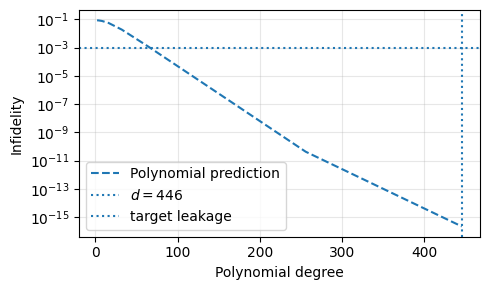

In [3]:
pi = np.array([0.50, 0.25, 0.15, 0.10])
spectral_gap = 1e-3

# Column-stochastic reversible chain with stationary distribution pi.
P = (1.0 - spectral_gap) * np.eye(len(pi)) + spectral_gap * pi[:, None]

target_suppression = 1e-3
phase_gap = np.arccos(1.0 - spectral_gap)
baseline_degree = int(
    np.ceil(
        2.0
        * np.log2(1.0 / target_suppression)
        / phase_gap
    )
)

degrees = sorted({ 2, 4, 8, 16, 32, 64, 128, 256, baseline_degree})

fig, ax, data = plot_spectral_filter_infidelity_vs_degree(
    P,
    degrees=degrees,
    include_qsvt=False,
)
ax.axvline(
    baseline_degree,
    linestyle=":",
    label=fr"$d={baseline_degree}$",
)
ax.axhline(
    target_suppression,
    linestyle=":",
    label="target leakage",
)
ax.legend()
plt.show()


<a id="annealing-schedule"></a>
## Annealing schedule

A direct projection from the uniform coherent state at $\beta_0=0$ to the target state at $\bar\beta$ can have exponentially small success probability. We therefore use

$$
0
=
\beta_0
<
\beta_1
<
\cdots
<
\beta_L
=
\bar\beta,
$$

with

$$
\left|
\braket{\pi_{\beta_{j+1}}}{\pi_{\beta_j}}
\right|^2
\geq
\frac{1}{e}.
$$

A general sufficient bound is

$$
\Delta\beta
\leq
\frac{1}{\|H\|}.
$$

Since $\|H\|\approx2n$ for the normalized SK instances, this worst-case rule requires $O(n\bar\beta)$ intermediate points.

A tighter local estimate follows from the Gibbs energy variance. The squared overlap is

$$
\left|
\braket{\pi_\beta}{\pi_{\beta+\Delta\beta}}
\right|^2
=
\frac{
Z(\beta+\Delta\beta/2)^2
}{
Z(\beta)Z(\beta+\Delta\beta)
}.
$$

Expanding symmetrically around the midpoint gives

$$
\log
\left|
\braket{\pi_\beta}{\pi_{\beta+\Delta\beta}}
\right|^2
=
-
\frac{
(\Delta\beta)^2
}{
4
}
\operatorname{Var}_{\pi_{\beta+\Delta\beta/2}}(H)
+
O((\Delta\beta)^4).
$$

Setting the squared overlap to $1/e$ yields

$$
\Delta\beta
\simeq
\frac{
2
}{
\sqrt{
\operatorname{Var}_{\pi_{\beta+\Delta\beta/2}}(H)
}
}.
$$


<a id="heuristic-sk-schedule"></a>
## Heuristic SK schedule

For the SK ensemble, define the disorder-averaged energy variance

$$
V(n,\beta)
=
\mathbb{E}_{H_n\sim\mathrm{SK}}
\left[
\operatorname{Var}_{\pi_\beta}(H_n)
\right].
$$

The numerical data support the extensive form

$$
V(n,\beta)
\simeq
n\,v(\beta).
$$

The final reduced ansatz is

$$
v_{\mathrm{fit}}(\beta)
=
\begin{cases}
\exp\left[
\log(v_1)\beta
+
\kappa\beta(1-\beta)
\right],
&
\beta<1,
\\[2mm]
v_1
\left(
1+
\dfrac{\beta-1}{\tau}
\right)^{-7/2},
&
\beta\geq1.
\end{cases}
$$

The fitted parameters are

$$
v_1
=
0.36509,
\qquad
\kappa
=
1.23536,
\qquad
\tau
=
1.28646.
$$

To obtain a conservative envelope, the fit is multiplied by $4$ for $\beta<1$ and by $16$ for $\beta\geq1$. The resulting schedule rule is

$$
\Delta\beta(n,\beta)
=
\frac{1}{\sqrt n}
\begin{cases}
\exp\left(
-0.111\beta
+
0.615\beta^2
\right),
&
\beta<1,
\\[2mm]
0.533
(\beta+0.286)^{7/4},
&
\beta\geq1.
\end{cases}
$$

The schedule is generated recursively as

$$
\beta_{j+1}
=
\min\left\{
\bar\beta,
\beta_j+\Delta\beta(n,\beta_j)
\right\},
$$

and explicitly includes $\beta=1$ when the path crosses the transition point.


### Reproducing the variance fit

The data are generated by the programs in `estimation_variance/` and collected in `estimation_variance/var_energies.pkl`. The following cells reproduce the reduced fit and the conservative-envelope check.


In [4]:
variance_data = pd.read_pickle(
    "../estimation_variance/var_energies.pkl"
)

variance_data = variance_data[
    np.isfinite(variance_data["var_energy"])
    & (variance_data["var_energy"] > 0)
].copy()

variance_data["variance_density"] = (
    variance_data["var_energy"]
    / variance_data["n"]
)

aggregated_variance = (
    variance_data
    .groupby(["n", "beta"], as_index=False)
    .agg(
        V=("var_energy", "mean"),
        V_std=("var_energy", "std"),
        count=("var_energy", "count"),
    )
)


In [5]:
def variance_density_ansatz(
    parameters: np.ndarray,
    beta: np.ndarray,
) -> np.ndarray:
    """Return the reduced piecewise variance-density ansatz."""
    log_v1, kappa, log_tau = parameters

    v1 = np.exp(log_v1)
    tau = np.exp(log_tau)

    beta = np.asarray(beta, dtype=float)
    result = np.empty_like(beta)

    high_temperature = beta < 1.0
    result[high_temperature] = np.exp(
        log_v1 * beta[high_temperature]
        + kappa
        * beta[high_temperature]
        * (1.0 - beta[high_temperature])
    )
    result[~high_temperature] = (
        v1
        * (
            1.0
            + (beta[~high_temperature] - 1.0) / tau
        )
        ** (-3.5)
    )
    return result


def fit_variance_density(
    table: pd.DataFrame,
) -> np.ndarray:
    """Fit the reduced ansatz in logarithmic space."""
    n = table["n"].to_numpy(dtype=float)
    beta = table["beta"].to_numpy(dtype=float)
    target = table["V"].to_numpy(dtype=float)

    def residual(parameters: np.ndarray) -> np.ndarray:
        prediction = (
            n
            * variance_density_ansatz(parameters, beta)
        )
        return np.log(prediction) - np.log(target)

    initial_parameters = np.array(
        [
            np.log(0.36),
            1.25,
            np.log(1.3),
        ]
    )
    result = least_squares(
        residual,
        initial_parameters,
    )
    return result.x


fit_parameters = fit_variance_density(
    aggregated_variance
)
log_v1, kappa, log_tau = fit_parameters

print(f"v1 = {np.exp(log_v1):.5f}")
print(f"kappa = {kappa:.5f}")
print(f"tau = {np.exp(log_tau):.5f}")


v1 = 0.37108
kappa = 1.21638
tau = 1.28274


In [6]:
fitted_density = variance_density_ansatz(
    fit_parameters,
    variance_data["beta"].to_numpy(dtype=float),
)

ratio = (
    variance_data["variance_density"].to_numpy()
    / fitted_density
)

high_temperature = (
    variance_data["beta"].to_numpy(dtype=float) < 1.0
)

print(
    "maximum ratio for beta < 1:",
    np.max(ratio[high_temperature]),
)
print(
    "maximum ratio for beta >= 1:",
    np.max(ratio[~high_temperature]),
)


maximum ratio for beta < 1: 2.512701163645821
maximum ratio for beta >= 1: 13.590488974830897


The release implementation is `tight_schedule_annealing` in `monaqa2.data.runtime`. It returns the filter points $\beta_1,\ldots,\beta_L$ and omits the initial point $\beta_0=0$, which is prepared directly.


In [7]:
n = 50
target_beta = 4.0

schedule = tight_schedule_annealing(
    n,
    target_beta,
)

print("number of filters:", len(schedule))
print("schedule:", np.asarray(schedule))


number of filters: 17
schedule: [0.14142136 0.28236301 0.42630851 0.57714448 0.73994646 0.92237071
 1.         1.11706145 1.25340243 1.41376703 1.60449907 1.8342467
 2.11506047 2.46415868 2.9068676  3.48172325 4.        ]


<a id="zeno-rewind"></a>
## Zeno-rewind query count

Let

$$
p_j
=
\left|
\braket{\pi_{\beta_j}}{\pi_{\beta_{j-1}}}
\right|^2
\geq
p_0.
$$

If the filters were applied once and the complete path were restarted after any failure, the success probability would be at least $p_0^L$. Instead, the rewind protocol alternates the filters at $\beta_j$ and $\beta_{j-1}$ after a failed transition.

If $d_j$ is the number of walk calls used by the filter at $\beta_j$, the exact expected cost of the transition is

$$
N_j
=
\left(
1+\frac{1}{2p_j}
\right)d_j
+
\frac{1}{2p_j}d_{j-1}.
$$

With $d_0=0$ and $p_j\geq p_0$, summing over the schedule gives

$$
\sum_{j=1}^L N_j
\leq
\left(
1+\frac{1}{p_0}
\right)
\sum_{j=1}^Ld_j.
$$

For $p_0=1/e$, the expected overhead is bounded by $1+e$.

The total filter-error budget is divided among the expected filter applications:

$$
\varepsilon_{\mathrm{filter}}
=
\frac{
\varepsilon_{\mathrm{FLT}}
}{
(1+e)L
}.
$$

Hence,

$$
Q^{\mathrm q}(n,\bar\beta,\varepsilon)
=
2(1+e)
\log_2
\left(
\frac{
4(1+e)L
}{
\varepsilon
}
\right)
\sum_{j=1}^L
\frac{
1
}{
\theta_{\beta_j}(n)
},
$$

where the final expression uses $\varepsilon_{\mathrm{FLT}}=\varepsilon/4$.


The runtime module performs this accounting through `get_quantum_annealing_error_budget`.


In [8]:
example_spectral_gaps = [
    1e-2,
    5e-3,
    2e-3,
]

budget = get_quantum_annealing_error_budget(
    eps_TV=1e-2,
    spectral_gaps=example_spectral_gaps,
)

for key, value in budget.items():
    print(f"{key}: {value}")


eps_TV: 0.01
eps_SF: 0.0025
eps_MS: 0.0025
eps_FLT: 0.0025
eps_W_budget: 0.0025
eps_W: 8.436162083131522e-07
degree_filters: [np.longdouble('171.30846299928400375'), np.longdouble('242.36799584507368623'), np.longdouble('383.3133889080799713')]
queries_per_step: [np.longdouble('636.97314503148639714'), np.longdouble('901.1925147507748295'), np.longdouble('1425.267208581968649')]
total_queries: 2963.4328683642298


<a id="logical-resources"></a>
## Logical resources of one walk

The release runtime model uses the hybrid Boltzmann coin. Let

$$
M
=
n+\binom n2,
\qquad
w
=
b+1,
\qquad
s_{\mathrm{SK}}
=
\left\lceil
\log_{3/2}(2M)
\right\rceil,
\qquad
\ell_x
=
\left\lceil
\log_2x
\right\rceil.
$$

The paper chooses the fixed-point precision from

$$
b
\geq
\left\lceil
\log_2
\left(
\frac{
2M\beta\Lambda
}{
\varepsilon_{\mathrm{discr}}
}
\right)
\right\rceil,
\qquad
\Lambda
\simeq
\frac{
2
}{
\sqrt\pi
}
n^{3/2}.
$$

The cutoff power is

$$
j_{\mathrm{cut}}
=
\max
\left\{
0,
\min
\left[
w-1,
\left\lfloor
\log_2
\left(
\frac{
\beta\Lambda
}{
2\log(1/\varepsilon_{\mathrm{tail}})
}
\right)
\right\rfloor
\right]
\right\}.
$$

In the active-tail regime, the hybrid polynomial degree is estimated as

$$
d_{\mathrm{hyb}}
\approx
\left\lceil
\log
\left(
\varepsilon_{\mathrm{tail}}^{-1}
\right)
+
\log
\left(
\varepsilon_{\mathrm{ops}}^{-1}
\right)
+
1
\right\rceil.
$$

The hybrid coin has non-Clifford depth

$$
D_{\mathrm{hyb}}
=
d_{\mathrm{hyb}}
(54\ell_w-18)
+
36s_{\mathrm{SK}}
+
42w
-
6j_{\mathrm{cut}}
+
28\ell_{j_{\mathrm{cut}}}
-
17,
$$

and logical-qubit count

$$
S_{\mathrm{hyb}}
=
2n+6Mw-2M+2.
$$

The proposal resources are

| Proposal | Non-Clifford depth | Logical qubits |
|---|---:|---:|
| Local | $2\ell_n$ | $2n$ |
| Uniform | $0$ | $2n$ |
| Hamiltonian simulation | $r(n+3)$ | $2n$ |

The reflection and accept-path resources are

| Component | Non-Clifford depth | Logical qubits |
|---|---:|---:|
| Reflection | $14\ell_{n+w}-10$ | $2n+w+3$ |
| Accept path | $28\ell_{w+1}-11$ | $3n+w+1$ |

For proposal depth $D_V$, one walk application has

$$
D_W
=
2D_V
+
2D_{\mathrm{hyb}}
+
14\ell_{n+w}
-
10
+
28\ell_{w+1}
-
11.
$$

Its logical space is the maximum qubit count among the proposal, hybrid coin, reflection, and accept-path blocks.


The following calls expose the complete resource model implemented by the runtime module.


In [9]:
n = 50
beta = 4.0
eps_W = 1e-10

for name, resource_function in [
    ("local", quantum_walk_local_circuit),
    ("uniform", quantum_walk_uniform_circuit),
]:
    depth, qubits = resource_function(
        n,
        eps_W,
        beta,
    )
    print(
        f"{name:8s}: "
        f"depth={depth:.6e}, "
        f"qubits={qubits:.6e}"
    )

depth, qubits = quantum_walk_qemc_circuit(
    n,
    eps_W,
    beta,
    num_trotter_steps=50,
)
print(
    "Hamiltonian simulation: "
    f"depth={depth:.6e}, "
    f"qubits={qubits:.6e}"
)


local   : depth=5.509700e+04, qubits=1.076202e+06
uniform : depth=5.507300e+04, qubits=1.076202e+06
Hamiltonian simulation: depth=6.037300e+04, qubits=1.076202e+06


<a id="clifford-phi-model"></a>
## Clifford+$\phi$ fault-tolerant model

Appendix F expands the logical circuits into the Clifford+$T$+$R_z$ gate set and counts the resulting non-Clifford depth. The fault-tolerant model then rewrites these non-Clifford rotations as Pauli-product measurements.

Clifford operations are propagated through a Pauli or Clifford frame and update the Pauli products measured later. Their execution cost is therefore neglected. The online resource-consuming operations are:

* $T$ rotations, supplied by $\ket T$ resource states;
* arbitrary $R_z(\theta)$ rotations, supplied by angle-specific $\ket{R_z(\theta)}$ resource states.

All logical gates have already been reduced to these rotations before the PPM mapping. The PPM model does not introduce any additional non-Clifford resource class.

An arbitrary-angle injection may produce $R_z(-\theta)$ instead of $R_z(\theta)$. The correction sequence then uses $R_z(2\theta)$, $R_z(4\theta)$, and so on. The expected number of injected rotations is two. Factory throughput, delivery latency, and correction delays are not scheduled explicitly; their uncertainty is absorbed into the range of physical operation times.


<a id="error-budget"></a>
## Error budget

Let $\varepsilon$ be the target total-variation error. The model divides it equally:

$$
\varepsilon
=
\varepsilon_{\mathrm{QEC}}
+
\varepsilon_{\mathrm{MS}}
+
\varepsilon_{\mathrm{FLT}}
+
\varepsilon_W^{\mathrm{tot}},
$$

with

$$
\varepsilon_{\mathrm{QEC}}
=
\varepsilon_{\mathrm{MS}}
=
\varepsilon_{\mathrm{FLT}}
=
\varepsilon_W^{\mathrm{tot}}
=
\frac{\varepsilon}{4}.
$$

Here:

* $\varepsilon_{\mathrm{QEC}}$ bounds logical failures in the surface-code layer;
* $\varepsilon_{\mathrm{MS}}$ bounds failures of the injected resource states;
* $\varepsilon_{\mathrm{FLT}}$ bounds leakage from all spectral filters;
* $\varepsilon_W^{\mathrm{tot}}$ bounds errors in all implementations of $W_\beta$ and $W_\beta^\dagger$.

If the expected total number of walk calls is $Q^{\mathrm q}$, the per-walk implementation budget is

$$
\varepsilon_W
=
\frac{
\varepsilon_W^{\mathrm{tot}}
}{
Q^{\mathrm q}
}.
$$

The runtime code names $\varepsilon_{\mathrm{QEC}}$ as `eps_SF`, but it represents the same surface-code failure budget.


<a id="surface-code-runtime"></a>
## Surface-code runtime

Let $D$ be the total logical non-Clifford depth and $S$ the maximum logical-qubit count. The logical spacetime volume is

$$
V_{\mathrm{st}}
=
DS.
$$

For physical error rate $p_{\mathrm{phys}}$ and threshold $p_*=10^{-2}$, the logical error model is

$$
p_L(d)
=
0.03
\left(
\frac{
p_{\mathrm{phys}}
}{
p_*
}
\right)^{(d+1)/2}.
$$

The code distance is the smallest odd $d\geq3$ satisfying

$$
V_{\mathrm{st}}
p_L(d)
\leq
\varepsilon_{\mathrm{QEC}}.
$$

One lattice-surgery layer lasts

$$
d
\left(
4t_{\mathrm{op}}
+
t_{\mathrm{mr}}
\right),
$$

where $t_{\mathrm{mr}}$ includes measurement and reset. The physical runtime is therefore

$$
T
=
D
d
\left(
4t_{\mathrm{op}}
+
t_{\mathrm{mr}}
\right).
$$


In [10]:
logical_depth = 1e12
logical_qubits = 1e5
physical_error_rate = 1e-3
eps_QEC = 1e-2 / 4

distance = rotated_surface_code_distance(
    spacetime_volume=logical_depth * logical_qubits,
    physical_error_rate=physical_error_rate,
    eps_SF=eps_QEC,
)

runtime = rotated_surface_code_time(
    logical_time=logical_depth,
    logical_space=logical_qubits,
    physical_operation_time=20e-9,
    physical_measurement_time=200e-9,
    physical_error_rate=physical_error_rate,
    eps_SF=eps_QEC,
)

print("surface-code distance:", distance)
print("runtime [s]:", runtime)


surface-code distance: 37.0
runtime [s]: 10359999.999999998


<a id="end-to-end-runtime"></a>
## End-to-end runtime

### Classical walks

For classical query counts $q_j$ along the schedule, $Q^{\mathrm c}=\sum_jq_j$. The fitted single-step latencies are:

| Device | Local proposal | Uniform proposal |
|---|---:|---:|
| CPU | $5.959\times10^{-9}+1.429\times10^{-10}n$ | $1.173\times10^{-8}n+6.964\times10^{-11}n^2$ |
| GPU | $7.837\times10^{-7}+1.459\times10^{-9}n$ | $2.215\times10^{-10}n^2$ |
| FPGA | $2.679\times10^{-7}+1.800\times10^{-9}\log_2n$ | $2.541\times10^{-7}+4.200\times10^{-9}\log_2n$ |

All entries are in seconds. The total classical runtime is $Q^{\mathrm c}$ times the selected single-step latency.

### Quantum walks

For schedule points $\beta_j$, expected query counts $q_j^{\mathrm q}$, walk depths $D_W(\beta_j)$, and walk spaces $S_W(\beta_j)$,

$$
D_{\mathrm{tot}}
=
\sum_{j=1}^L
q_j^{\mathrm q}
D_W(\beta_j),
$$

and

$$
S_{\mathrm{tot}}
=
\max_j
S_W(\beta_j).
$$

The full spacetime volume $D_{\mathrm{tot}}S_{\mathrm{tot}}$ determines one surface-code distance for the complete computation. The runtime is then obtained from the previous section.


### Example using fitted spectral gaps

This cell reproduces one complete quantum-runtime evaluation. The schedule contains the target inverse temperatures at which filters are applied, and the fitted spectral gap is evaluated at each of those points.


In [11]:
from monaqa2.data.spectral_gap import (
    get_spectral_gap_fit_by_n,
)

n = 50
target_beta = 4.0
eps_TV = 1e-2

betas = tight_schedule_annealing(
    n,
    target_beta,
)

spectral_gaps = []
for beta_j in betas:
    prefactor, exponent = get_spectral_gap_fit_by_n(
        proposal="qemc",
        a=np.inf,
        fixed_beta=beta_j,
    )
    spectral_gaps.append(
        prefactor * np.exp(-exponent * n)
    )

runtime_seconds = get_annealing_time_quantum_walk_qemc(
    n=n,
    eps_TV=eps_TV,
    betas=betas,
    spectral_gaps=spectral_gaps,
    physical_operation_time=20e-9,
    physical_measurement_time=200e-9,
    physical_error_rate=1e-3,
    num_trotter_steps=50,
)

print("number of annealing filters:", len(betas))
print("runtime [s]:", runtime_seconds)


number of annealing filters: 17
runtime [s]: 284411.5144146561466


<a id="model-assumptions"></a>
## Model assumptions

* The logical runtime is identified with the non-Clifford depth after recursive decomposition into Clifford+$T$+$R_z$ gates.

* All PPMs associated with one non-Clifford layer are assumed to execute in parallel. Layout-dependent routing conflicts and modular-interconnect constraints are not scheduled explicitly.

* The logical-space count includes algorithmic qubits and circuit ancillas, but excludes routing patches and resource-state factories.

* Resource states are assumed to be available when consumed. Factory throughput, delivery latency, and probabilistic arbitrary-angle corrections are absorbed into the range of physical operation times.

* The hybrid arithmetic uses the active-tail resource formula when $3\leq j_{\mathrm{cut}}\leq w-1$. The runtime code separately handles $j_{\mathrm{cut}}\in\{0,1,2\}$.

* The heuristic annealing rule is an empirical disorder-averaged schedule for the normalized SK ensemble. It is not a rigorous instance-wise overlap guarantee.

* The fitted spectral gaps are extrapolations from the numerically accessible range. The runtime estimates should therefore be interpreted as representative resource projections rather than certified bounds.
